                                                                    TP 4

                                                                Montalat Manel
                                                              Gauto Ángel Nicolás

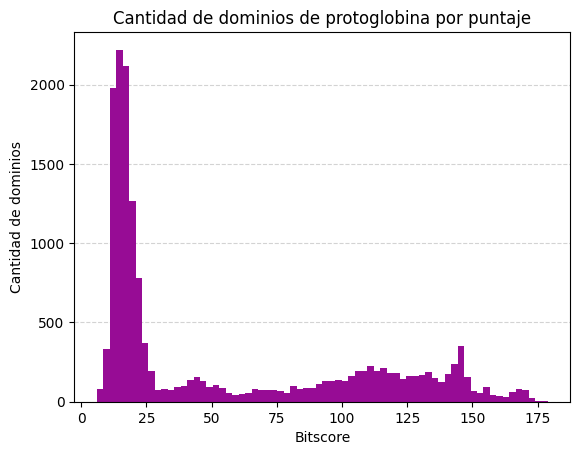

In [12]:
#Ejercicio 2.a

from Bio import SearchIO
import matplotlib.pyplot as plt

def puntajes(resultados: list) -> list:
    lista_puntajes = []
    for hit in resultados:
        for dominio in hit:
            lista_puntajes.append(dominio.bitscore)
    return lista_puntajes

result_proto = SearchIO.read("busqueda.out", "hmmer3-text")
puntajes_proto = puntajes(result_proto)

def graf_histograma_puntajes(elementos: str, titulo: str, nombre: str):
    plt.hist(elementos, bins=70, color="#970c95", zorder=2)
    plt.grid(axis="y", linestyle="--", color="lightgrey", zorder=1)
    plt.title(titulo)
    plt.xlabel("Bitscore")
    plt.ylabel("Cantidad de dominios")
    plt.savefig(nombre)

graf_histograma_puntajes(puntajes_proto, "Cantidad de dominios de protoglobina por puntaje", "histograma protoglobina")


En el histograma podemos ver un pico muy alto entre 0 y 25, y una "colina aplanada" entre 75 - 175 aproximadamente, esto nos indica que el HMM esta discriminando correctamente entre secuencias relacionadas y no relacionadas.

El primer pico grande corresponde a alineamientos débiles, proteínas que
no pertenecen a la familia, similitudes aleatorias o match parciales. El segundo pico representa secuencias que alinean muy bien con el HMM, conservan posiciones importantes y cubren gran parte del modelo,
por lo que podríamos afirmar que tienen patrones típicos de globinas.

In [13]:
#Ejercicio 2.b IDs preguntar si los querían así

from Bio import SeqIO
import pandas as pd

def extraerPosiciones(resultados: list, puntaje_corte: float):
    lista = []
    for secuencia in resultados:
        for dominio in secuencia:
            if dominio.bitscore > puntaje_corte:
                raw_id = dominio.hit_id
                lista.append((uniprotID(raw_id), dominio.hit_start, dominio.hit_end))
    return lista

def uniprotID(id: str):
    if "|" in id:
        return id.split("|")[1]
    else:
        return id

#Viendo el histograma, inferimos que los puntajes menores a 50 son "ruido"

lista_ids = extraerPosiciones(result_proto, 50)
print("Cantidad de dominios de protoglobina encontrados:",len(lista_ids))
df = pd.DataFrame(lista_ids, columns=["ID", "Inicio", "Fin"])
df.head()

Cantidad de dominios de protoglobina encontrados: 5955


,ID,Inicio,Fin
0,G0RZQ1,19,200
1,A0A175VX62,20,200
2,B2AU65,20,200
3,A0A3E0RFZ9,36,190
4,F7VKQ0,26,207


In [14]:
#Ejercicio 2.b archivo fasta (VER SI HAY QUE AÑADIR LA DESCRIPCION AL CODIGO)

from Bio.SeqRecord import SeqRecord

def guardarDominios(lista: list, nombre: str):
    fasta_inicial = SeqIO.to_dict(SeqIO.parse("globin_full_seq.fasta", "fasta"))
    fasta = {}
    for key, value in fasta_inicial.items():
        nuevo = uniprotID(key)
        valor = fasta_inicial[key]
        fasta[nuevo] = valor

    registros_nuevos = []
    for uid, start, end in lista:
        if uid in fasta:
            seq = fasta[uid]
            dominio = seq.seq[start-1:end]
            nuevo = SeqRecord(
                dominio,
                id = uid + "/" + str(start) + "-" + str(end),
                description = ""
            )
            registros_nuevos.append(nuevo)

    SeqIO.write(registros_nuevos, nombre, "fasta")

guardarDominios(lista_ids, "proto_salida.fasta")

Ejercicio 2.c

En el ejercicio anterior, vimos la longitud de la lista de ids y vimos que encontramos 5955 dominios candidatos a protoglobina a partir de la minería de datos realizada con el HMM construido desde el seed de Pfam

Aunque no podemos afirmar que no hallamos excluído algunos ya que los filtramos con un umbral definido por nosotros, lo que pudo haber excluido falsos negativos (protoglobinas muy divergentes). 

Tampoco podemos afirmar que todos los dominios hallados sean protoglobina, ya que el HMM detecta similitud estadística con el modelo, por lo tanto hay chance de haber incluído falsos positivos (globinas similares).

In [15]:
#Ejercicio 3.a 
#En Jalview se observa la histidina conservada
#En MAFFT es 368, en HMM es 261. Python lee desde la columna 0

from Bio import AlignIO

def histidinaF8(archivo: str, formato: str, columna: int) -> float:
    align = AlignIO.read(archivo, formato)
    align_pd = pd.DataFrame(align)
    col = align_pd[columna - 1]
    aminos = col[col != "-"]
    cantidad_histidina = (aminos == "H").sum()
    return round((cantidad_histidina / len(aminos) * 100), 2)

def calcula_gaps(archivo: str, formato: str, columna: int) -> float:
    align = AlignIO.read(archivo, formato)
    df = pd.DataFrame(align)
    col = df[columna - 1]
    gaps = (col == "-").sum()
    return round(gaps / len(col) * 100, 2)

print("Porcentaje de histidina en F8 según MAFFT:",
    histidinaF8("/home/pizza/Escritorio/Bioinformática/TP 4/dominios_mafft.fasta", "fasta", 368))
print("Porcentaje de histidina en F8 según HMMalign:",
    histidinaF8("/home/pizza/Escritorio/Bioinformática/TP 4/alin_seqs.sto", "stockholm", 261))
print("Porcentaje de gaps en F8 según MAFFT:",
    calcula_gaps("/home/pizza/Escritorio/Bioinformática/TP 4/dominios_mafft.fasta", "fasta", 368))
print("Porcentaje de gaps en F8 según HMMalign:",
    calcula_gaps("/home/pizza/Escritorio/Bioinformática/TP 4/alin_seqs.sto", "stockholm", 261))

Porcentaje de histidina en F8 según MAFFT: 94.04
Porcentaje de histidina en F8 según HMMalign: 93.76
Porcentaje de gaps en F8 según MAFFT: 2.2
Porcentaje de gaps en F8 según HMMalign: 2.0


En ambos alineamientos se identificaron columnas altamente conservadas correspondientes a la histidina F8, lo cual era esperable al ser un aminoácido tan esencial para la función de estas proteínas. Además el porcentaje de histidina en dichas posiciones fue muy similar al comparar los dos métodos de alineamiento (94,04% para MAFFT y 93,76% hmmalign) al igual que la proporción de gaps observada (2.2% y 2.0%, respectivamente). 

Sin embargo, la histidina F8 se localiza en columnas diferentes según el alineamiento, ya que en el MSA hecho por MAFFT se encuentra en la columna 368 y en el MSA hecho por HMMER la histidina está en la columna 261. Esto es debido a las diferencias en la estrategia de alineamiento que utiliza cada método. Mientras MAFFT realiza el alineamiento a partir de similitud de secuencias, hmmalign utiliza además de esto la información contenida en el perfil HMM previamente entrenado, el cual incorpora patrones evolutivos y posiciones conservadas de la familia de las protoglobinas.

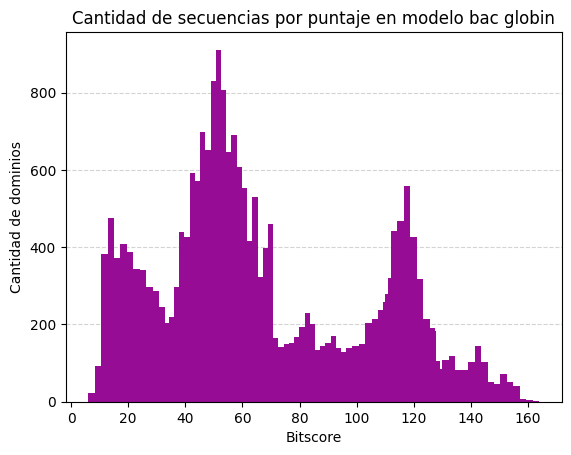

In [16]:
#Ejercicio 3.b.2

result_globin = SearchIO.read("globin.out", "hmmer3-text")
puntajes_globin = puntajes(result_globin)
graf_histograma_puntajes(puntajes_globin, "Cantidad de secuencias por puntaje en modelo globin", "histograma globin")

result_bac_globin = SearchIO.read("bac_globin.out", "hmmer3-text")
puntajes_bac_globin = puntajes(result_bac_globin)
graf_histograma_puntajes(puntajes_bac_globin,
                         "Cantidad de secuencias por puntaje en modelo bac globin", 
                         "histograma bac_globin")

#Analizando los histogramas, consideramos que las secuencias con puntaje menor a 73 en ambos son "ruido"

ids_globin = extraerPosiciones(result_globin, 73)
guardarDominios(ids_globin, "globin_salida.fasta")
ids_bac_globin = extraerPosiciones(result_bac_globin, 73)
guardarDominios(ids_bac_globin, "bac_globin_salida.fasta")

In [17]:
#Ejercicio 3.b.3

set_proto = set(x[0] for x in lista_ids)
set_globin = set(x[0] for x in ids_globin)
set_bac_globin = set(x[0] for x in ids_bac_globin)

compartidos = set_bac_globin & set_globin & set_proto
print("Aparecen en los 3 sets:", compartidos)

Aparecen en los 3 sets: set()


No existen secuencias compartidas entre los 3 dominios. Esto puede suceder por haber puesto el umbral alto.

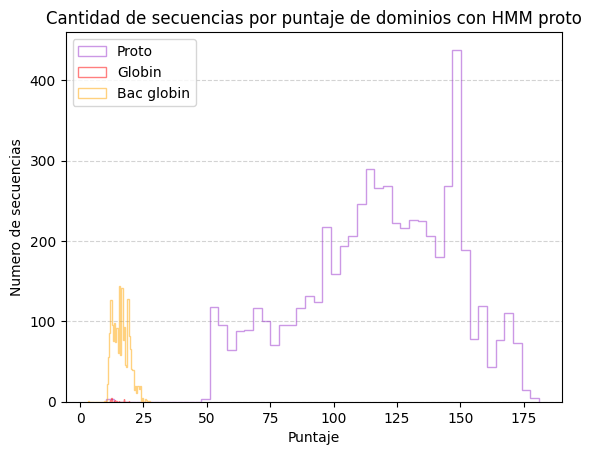

In [18]:
#Ejercicio 3.d modelo de proto
def modelo_resultados(modelo: str):
    proto = SearchIO.read(modelo + "VSproto.out", "hmmer3-text")
    result_p = puntajes(proto)
    globin = SearchIO.read(modelo + "VSglobin.out", "hmmer3-text")
    result_g = puntajes(globin)
    bac = SearchIO.read(modelo + "VSbac_globin.out", "hmmer3-text")
    result_b = puntajes(bac)
    return result_p, result_g, result_b

def hist_compara(proto: list, globin: list, bac: list, titulo: str, nombre: str):
    plt.hist(proto, histtype="step",  bins=50, alpha=0.5, label="Proto", color="darkorchid", zorder=3)
    plt.hist(globin, histtype="step", bins=50, alpha=0.5, label="Globin", color="red", zorder=3)
    plt.hist(bac, histtype="step", bins=50, alpha=0.5, label="Bac globin", color="orange", zorder=3)
    plt.grid(axis="y", linestyle="--", color="lightgrey", zorder=0)
    plt.legend()
    plt.title(titulo)
    plt.xlabel("Puntaje")
    plt.ylabel("Numero de secuencias")
    plt.savefig(nombre)

pvp, pvg, pvb = modelo_resultados("proto")
hist_compara(pvp, pvg, pvb,
             "Cantidad de secuencias por puntaje de dominios con HMM proto",
             "histograma proto vs dominios")


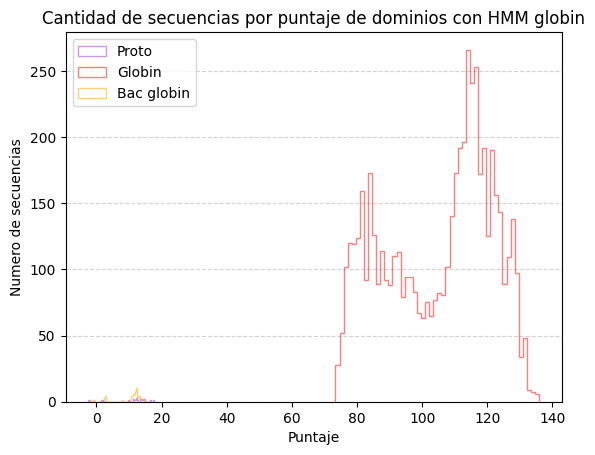

In [19]:
#Ejercicio 3.d modelo de globin

gvp, gvg, gvb = modelo_resultados("globin")
hist_compara(gvp, gvg, gvb,
             "Cantidad de secuencias por puntaje de dominios con HMM globin",
             "histograma globin vs dominios")

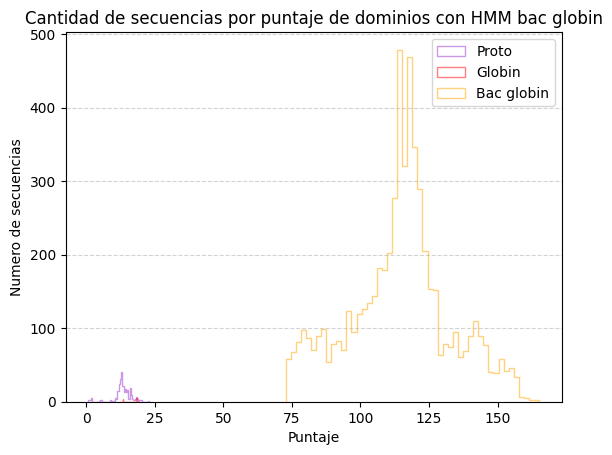

In [20]:
#Ejercicio 3.d modelo de bac globin

bvp, bvg, bvb = modelo_resultados("bac_globin")
hist_compara(bvp, bvg, bvb,
             "Cantidad de secuencias por puntaje de dominios con HMM bac globin",
             "histograma bac globin vs dominios")

En los histogramas obtenidos muestran que cada HMM asigna los puntajes más altos principalmente al conjunto de secuencias correspondientes a su propia familia, mientras que las secuencias pertenecientes a otras familias de globinas presentan en general puntajes bajos. Esto indica que los modelos construidos tienen una buena capacidad para discriminar y reconocer las señales de conservación característicos de cada grupo.

Se puede observar solapamiento pero ocurre en las zonas de puntaje bajo, y pasa entre dominios que no deberían encajar en el HMM con el que se contrastó (Por ejemplo, en el HMM Bac globin los dominios en bac globin sacaron puntajes altos, mientras que globin y proto sacaron puntajes bajos). Esto ocurre porque al poner el umbral para filtrar que secuencias pertenecen a los dominios, fue puesto de forma que encajan bien con el HMM elegido y las secuencias con menor puntaje que podrían sacar mayor puntaje en otro modelo no se incluyeron en el dominio. Es posible que si se elige un umbral mas bajo, en los histogramas se observe un solapamiento entre los dominios que no pertenecen al modelo y el dominio propio del dominio.